In [ ]:
from graphviz import Digraph

# Configuración del gráfico
dot = Digraph(comment='Web Scraping Mercado Libre',
              format='png',
              graph_attr={
                  'rankdir': 'TB',  # Vertical (Top to Bottom)
                  'bgcolor': '#f7f7f7',
                  'compound': 'true',
                  'fontname': 'Helvetica',
                  'fontsize': '12',
                  'label': '\nProceso de Extracción de Datos - Mercado Libre\n',
                  'labelloc': 't',
                  'fontcolor': '#333333',
                  'penwidth': '0.5',
                  'splines': 'ortho'  # Líneas rectas
              })

# Estilo global
dot.attr('node',
         shape='Mrecord',  # Forma rectangular con bordes redondeados
         style='filled, rounded',
         fillcolor='#ffffff',
         color='#2c3e50',
         fontname='Helvetica',
         fontsize='11',
         margin='0.2,0.1',
         penwidth='1.2')

dot.attr('edge',
         color='#7f8c8d',
         arrowsize='0.8',
         penwidth='1.2')

# Nodos personalizados (con detalles y colores)
dot.node('A', 'INICIO',
         shape='ellipse',
         fillcolor='#27ae60',
         fontcolor='white',
         style='filled, bold')

dot.node('B', '{Solicitud HTTP|{Método: GET|URL: Página de resultados}}',
         fillcolor='#3498db',
         fontcolor='white')

dot.node('C', '{Parseo HTML|{Herramienta: BeautifulSoup|Datos extraídos:|• Precio actual\\l• Precio anterior\\l• Descuento\\l• Calificación\\l• Enlace\\l}}',
         fillcolor='#9b59b6',
         fontcolor='white')

dot.node('D', '{Acceso a producto|{Seguir enlace|Timeout: 5 segundos}}',
         fillcolor='#e67e22',
         fontcolor='white')

dot.node('E', '{Extracción de reseñas|{Límite: 5 reseñas|Filtro: Estrellas ≥ 3}}',
         fillcolor='#1abc9c',
         fontcolor='white')

dot.node('F', '{Almacenamiento|{Formato: Diccionario Python|Claves: Precio, Reseñas, etc.}}',
         fillcolor='#f39c12',
         fontcolor='white')

dot.node('G', '{Exportación|{Formato: CSV|Archivo: laptops_data_raw.csv}}',
         fillcolor='#e74c3c',
         fontcolor='white')

dot.node('H', 'FIN',
         shape='ellipse',
         fillcolor='#c0392b',
         fontcolor='white',
         style='filled, bold')

# Conexiones con etiquetas opcionales
dot.edges(['AB', 'BC', 'CD', 'DE', 'EF', 'FG', 'GH'])

# Añadir notas decorativas (opcional)
dot.node('note', 'Nota: Este proceso se repite por cada página de resultados',
         shape='note',
         fillcolor='#f8f9fa',
         color='#95a5a6',
         fontsize='10',
         margin='0.15')

dot.edge('G', 'note',
         style='dashed',
         color='#95a5a6',
         arrowhead='none')

# Guardar y mostrar
dot.render('web_scraping_mercado_libre_vertical', view=True, cleanup=True)

'web_scraping_mercado_libre_vertical.png'

In [ ]:


# Inicializar colorama para colores en la terminal
init()

# Listas expandidas para generar reseñas más variadas
positive_phrases = [
    "¡Me encanta esta laptop! La pantalla es súper nítida y los colores son vibrantes.",
    "Realmente impresionado con la velocidad, abre todas mis aplicaciones en segundos.",
    "La batería dura todo el día, perfecto para trabajar fuera de casa.",
    "El diseño es elegante, se siente de alta calidad en cada detalle.",
    "Ideal para estudiantes, la uso para mis clases y nunca me ha fallado.",
    "No esperaba tanto por este precio, una grata sorpresa.",
    "El teclado es un sueño, escribir por horas no es ningún problema.",
    "Perfecta para gaming ligero, corre mis juegos favoritos sin problemas.",
    "La calidad de construcción es sólida, se nota que está hecha para durar.",
    "Para mi trabajo de diseño gráfico, esta laptop ha sido una maravilla."
]

positive_minor_issues = [
    "aunque la cámara no es la mejor para videollamadas.",
    "pero el ventilador se activa con frecuencia cuando la uso mucho.",
    "excepto que se calienta un poco después de varias horas.",
    "salvo que el sonido podría ser más potente.",
    "aunque me gustaría que tuviera más puertos USB.",
    "pero el peso es un poco mayor de lo que esperaba.",
    "aunque tarda un poco en cargar al 100%.",
    "pero a veces las bisagras de la pantalla se sienten algo rígidas.",
    "aunque el brillo de la pantalla podría ser mejor en exteriores.",
    "pero el touchpad no siempre responde como quisiera."
]

neutral_phrases = [
    "Es una laptop decente para el precio, pero no destaca en nada especial.",
    "Funciona bien para navegar y ver videos, aunque a veces se traba con varias pestañas.",
    "La batería dura lo suficiente para un día ligero, pero no para jornadas largas.",
    "Está bien para tareas básicas, pero no la recomendaría para trabajos pesados.",
    "El diseño es simple, cumple, pero no es nada fuera de lo común.",
    "Para el uso que le doy está bien, aunque esperaba un poco más de velocidad.",
    "Es útil para estudiar, pero el almacenamiento se llena rápido.",
    "No está mal, pero he tenido mejores experiencias con otras marcas.",
    "Cumple con lo básico, aunque la pantalla no es tan brillante como esperaba.",
    "Es aceptable para el precio, pero no esperes un rendimiento espectacular."
]

negative_phrases = [
    "Muy decepcionado, es demasiado lenta para mis necesidades.",
    "La pantalla se pixela mucho, no se ve bien para videos o juegos.",
    "Se calienta tanto que a veces tengo que apagarla para que se enfríe.",
    "La batería apenas dura un par de horas, muy frustrante.",
    "El teclado es incómodo, las teclas se sienten baratas y ruidosas.",
    "No vale la pena, se traba constantemente incluso con tareas básicas.",
    "La calidad de construcción deja mucho que desear, se siente frágil.",
    "No la recomiendo, el sistema operativo se cuelga todo el tiempo.",
    "Horrible experiencia, el sonido es tan bajo que apenas se escucha.",
    "Me arrepiento de haberla comprado, no cumple ni con lo mínimo."
]

# Palabras para añadir variedad emocional y de estilo
emphasis_words = ["realmente", "bastante", "súper", "totalmente", "para mi sorpresa", "honestamente", "sin duda", "en general"]
user_contexts = [
    "como estudiante, la uso para mis proyectos",
    "para mi trabajo remoto",
    "siendo gamer, la probé con algunos juegos",
    "para mis clases en línea",
    "en mi día a día como freelancer",
    "para ver series y películas",
    "como profesional de diseño",
    "para mis viajes de trabajo",
    "en mi rutina diaria",
    "para mis hijos en la escuela"
]

# Modelo de lenguaje simple basado en cadenas de Markov
class MarkovChain:
    def __init__(self):
        self.chain = defaultdict(list)

    def train(self, sentences):
        for sentence in sentences:
            words = sentence.split()
            for i in range(len(words) - 1):
                self.chain[words[i]].append(words[i + 1])
            # Asegurar que el último token tenga una transición vacía para terminar
            if words:
                self.chain[words[-1]].append(None)

    def generate_sentence(self, max_length=20):
        # Elegir una palabra inicial (que sea una palabra común para empezar)
        start_words = [word for word in self.chain.keys() if word[0].isupper() or word in ["La", "El", "Es"]]
        if not start_words:
            return "No se pudo generar una reseña."
        current_word = random.choice(start_words)
        sentence = [current_word]

        # Generar la frase palabra por palabra
        for _ in range(max_length - 1):
            next_words = self.chain.get(current_word, [None])
            next_word = random.choice(next_words)
            if next_word is None:
                break
            sentence.append(next_word)
            current_word = next_word

        return " ".join(sentence)

# Entrenar el modelo de Markov con las frases predefinidas
all_phrases = positive_phrases + positive_minor_issues + neutral_phrases + negative_phrases
markov_model = MarkovChain()
markov_model.train(all_phrases)

def extract_feature_from_name(name):
    """Extrae características del nombre del producto para personalizar reseñas."""
    features = []
    if "ram" in name.lower():
        ram = re.search(r'(\d+)\s*(gb)?\s*ram', name.lower())
        if ram:
            features.append(f"los {ram.group(1)} GB de RAM")
    if "ssd" in name.lower():
        ssd = re.search(r'(\d+)\s*(gb)?\s*ssd', name.lower())
        if ssd:
            features.append(f"el SSD de {ssd.group(1)} GB")
    if "intel" in name.lower():
        features.append("el procesador Intel")
    if "amd" in name.lower():
        features.append("el procesador AMD")
    if "windows" in name.lower():
        features.append("Windows")
    return features

def generate_reviews(rating, name, num_reviews=5):
    reviews = []
    if rating is None:
        return reviews  # Retornar lista vacía si no hay calificación
    rating = float(rating)  # Asegurarse de que la calificación sea un número

    # Extraer características del nombre para personalizar las reseñas
    features = extract_feature_from_name(name)
    has_features = len(features) > 0

    for _ in range(num_reviews):
        # Decidir aleatoriamente si usar el catálogo o el modelo de Markov
        use_markov = random.random() > 0.5  # 50% de probabilidad de usar Markov
        context = random.choice(user_contexts)
        emphasis = random.choice(emphasis_words)

        if rating >= 4.5:  # Alta calificación
            if use_markov:
                positive_comment = markov_model.generate_sentence()
                minor_issue = random.choice(positive_minor_issues)
                if has_features and random.random() > 0.5:
                    feature = random.choice(features)
                    review = f"{positive_comment} {emphasis}, {feature} hace que todo sea {random.choice(['rápido', 'fluido', 'eficiente'])} {context}, {minor_issue}"
                else:
                    review = f"{positive_comment} {emphasis} {context}, {minor_issue}"
            else:
                positive_comment = random.choice(positive_phrases)
                minor_issue = random.choice(positive_minor_issues)
                if has_features and random.random() > 0.5:
                    feature = random.choice(features)
                    review = f"{positive_comment} {emphasis}, {feature} hace que todo sea {random.choice(['rápido', 'fluido', 'eficiente'])} {context}, {minor_issue}"
                else:
                    review = f"{positive_comment} {emphasis} {context}, {minor_issue}"
        elif 3.5 <= rating < 4.5:  # Calificación regular
            if use_markov:
                neutral_comment = markov_model.generate_sentence()
                if has_features and random.random() > 0.5:
                    feature = random.choice(features)
                    review = f"{neutral_comment} {context}, aunque {feature} ayuda un poco."
                else:
                    review = f"{neutral_comment} {context}."
            else:
                neutral_comment = random.choice(neutral_phrases)
                if has_features and random.random() > 0.5:
                    feature = random.choice(features)
                    review = f"{neutral_comment} {context}, aunque {feature} ayuda un poco."
                else:
                    review = f"{neutral_comment} {context}."
        else:  # Baja calificación
            if use_markov:
                negative_comment = markov_model.generate_sentence()
                if has_features and random.random() > 0.5:
                    feature = random.choice(features)
                    review = f"{negative_comment} {context}, incluso con {feature}, no mejora la experiencia."
                else:
                    review = f"{negative_comment} {context}."
            else:
                negative_comment = random.choice(negative_phrases)
                if has_features and random.random() > 0.5:
                    feature = random.choice(features)
                    review = f"{negative_comment} {context}, incluso con {feature}, no mejora la experiencia."
                else:
                    review = f"{negative_comment} {context}."

        reviews.append(review)
    return reviews

def scrape_mercadolibre(pages=10):
    products = []
    omitted_count = 0
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36"
    }

    for page in range(1, pages + 1):
        url = f"https://listado.mercadolibre.com.mx/laptops#origin=q&page={page}"
        response = requests.get(url, headers=headers)

        if response.status_code != 200:
            print(f"{Fore.RED}Error en la página {page}: {response.status_code}{Style.RESET_ALL}")
            continue

        soup = BeautifulSoup(response.text, "html.parser")
        items = soup.find_all("li", class_="ui-search-layout__item")

        for item in items:
            try:
                # Extraer el vendedor primero
                seller_element = item.find("span", class_="poly-component__seller")
                seller = seller_element.text.strip() if seller_element else "Unknown"

                # Si el vendedor es "Unknown", omitir inmediatamente
                if seller == "Unknown":
                    omitted_count += 1
                    continue

                # Extraer los demás datos
                name_element = item.find("a", class_="poly-component__title")
                name = name_element.text.strip() if name_element else None

                current_price_element = item.find("span", class_="andes-money-amount--cents-superscript")
                current_price = current_price_element.find("span", class_="andes-money-amount__fraction").text.strip() if current_price_element else None

                previous_price_element = item.find("s", class_="andes-money-amount--previous")
                previous_price = previous_price_element.find("span", class_="andes-money-amount__fraction").text.strip() if previous_price_element else None

                discount_element = item.find("span", class_="andes-money-amount__discount")
                discount = discount_element.text.strip().replace("% OFF", "") if discount_element else None

                rating_element = item.find("span", class_="poly-reviews__rating")
                rating = rating_element.text.strip() if rating_element else None

                reviews_element = item.find("span", class_="poly-reviews__total")
                reviews = reviews_element.text.strip("()") if reviews_element else "0"

                # Generar reseñas ficticias basadas en la calificación y el nombre del producto
                reviews_text = generate_reviews(rating, name)

                # Solo agregar si el nombre existe
                if name:
                    products.append({
                        "Name": name,
                        "Current Price": current_price,
                        "Previous Price": previous_price,
                        "Discount": discount,
                        "Rating": rating,
                        "Reviews": reviews,
                        "Seller": seller,
                        "Reviews Text": reviews_text
                    })
                else:
                    omitted_count += 1

            except Exception as e:
                print(f"{Fore.RED}Error al procesar un producto: {e}{Style.RESET_ALL}")
                omitted_count += 1  # Contar como omitido si hay error

        print(f"{Fore.GREEN}Página {page} procesada.{Style.RESET_ALL}")

    # Resumen final
    print(f"\n{Fore.MAGENTA}=== Resumen ===")
    print(f"Total de productos recolectados: {len(products)}")
    print(f"Total de productos omitidos: {omitted_count}")
    print(f"===================={Style.RESET_ALL}")

    return products

# Ejecutar el scraping (20 páginas, como en el código original)
data = scrape_mercadolibre(pages=150)

# Crear DataFrame
df = pd.DataFrame(data)

if df.empty:
    print(f"{Fore.RED}El DataFrame está vacío. No se recolectaron datos.{Style.RESET_ALL}")
else:
    # Añadir columna indicadora de valores nulos en "Rating"
    df["Rating_Null"] = df["Rating"].isna().astype(int)

    # Convertir columnas a numéricas
    df["Current Price"] = pd.to_numeric(df["Current Price"].str.replace(",", ""), errors="coerce")
    df["Previous Price"] = pd.to_numeric(df["Previous Price"].str.replace(",", ""), errors="coerce")
    df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce")
    df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
    df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

    # Eliminar filas solo si "Name" o "Reviews Text" son nulas
    original_rows = len(df)
    df = df.dropna(subset=["Name", "Reviews Text"])
    deleted_rows = original_rows - len(df)
    percentage_deleted = (deleted_rows / original_rows) * 100 if original_rows > 0 else 0
    print(f"\n{Fore.YELLOW}Se eliminó el {percentage_deleted:.2f}% de las filas debido a valores nulos en 'Name' o 'Reviews Text'.{Style.RESET_ALL}")

    # Guardar los datos
    df.to_csv("laptops_data_clean_2025-05-17.csv", index=False)

    # Mostrar la tabla final
    print(f"\n{Fore.MAGENTA}Datos recolectados hoy (17 de mayo de 2025):{Style.RESET_ALL}")
    print(tabulate(df.head(5), headers="keys", tablefmt="fancy_grid", showindex=False))

Página 1 procesada.
Página 2 procesada.
Página 3 procesada.
Página 4 procesada.
Página 5 procesada.
Página 6 procesada.
Página 7 procesada.
Página 8 procesada.
Página 9 procesada.
Página 10 procesada.
Página 11 procesada.
Página 12 procesada.
Página 13 procesada.
Página 14 procesada.
Página 15 procesada.
Página 16 procesada.
Página 17 procesada.
Página 18 procesada.
Página 19 procesada.
Página 20 procesada.
Página 21 procesada.
Página 22 procesada.
Página 23 procesada.
Página 24 procesada.
Página 25 procesada.
Página 26 procesada.
Página 27 procesada.
Página 28 procesada.
Página 29 procesada.
Página 30 procesada.
Página 31 procesada.
Página 32 procesada.
Página 33 procesada.
Página 34 procesada.
Página 35 procesada.
Página 36 procesada.
Página 37 procesada.
Página 38 procesada.
Página 39 procesada.
Página 40 procesada.
Página 41 procesada.
Página 42 procesada.
Página 43 procesada.
Página 44 procesada.
Página 45 procesada.
Página 46 procesada.
Página 47 procesada.
Página 48 procesada.
P

In [ ]:
!pip install colorama

In [ ]:
import pandas as pd
from tabulate import tabulate
import requests
from bs4 import BeautifulSoup
import pandas as pd
from tabulate import tabulate
from colorama import init, Fore, Style
import random
import re
from collections import defaultdict
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from textblob import TextBlob
from tabulate import tabulate


In [ ]:


# Definir descripción de variables basada en los datos reales
table_data = [
    {"Variable": "Name", "Tipo": "Categórico", "Ejemplo": df["Name"].iloc[0] if not df["Name"].empty else "N/A"},
    {"Variable": "Current Price", "Tipo": "Numérico", "Ejemplo": df["Current Price"].iloc[0] if not df["Current Price"].empty else "N/A"},
    {"Variable": "Previous Price", "Tipo": "Numérico", "Ejemplo": df["Previous Price"].iloc[0] if not df["Previous Price"].empty else "N/A"},
    {"Variable": "Discount", "Tipo": "Numérico", "Ejemplo": df["Discount"].iloc[0] if not df["Discount"].empty else "N/A"},
    {"Variable": "Rating", "Tipo": "Numérico", "Ejemplo": df["Rating"].iloc[0] if not df["Rating"].empty else "N/A"},
    {"Variable": "Reviews", "Tipo": "Numérico", "Ejemplo": df["Reviews"].iloc[0] if not df["Reviews"].empty else "N/A"},
    {"Variable": "Seller", "Tipo": "Categórico", "Ejemplo": df["Seller"].iloc[0] if not df["Seller"].empty else "N/A"},
    {"Variable": "Reviews Text", "Tipo": "Texto", "Ejemplo": df["Reviews Text"].iloc[0][0] if not df["Reviews Text"].empty else "N/A"}
]
df_table_5_1 = pd.DataFrame(table_data)
print(tabulate(df_table_5_1, headers="keys", tablefmt="fancy_grid", showindex=False))

╒════════════════╤════════════╤════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Variable       │ Tipo       │ Ejemplo                                                                                                                                                                                │
╞════════════════╪════════════╪════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ Name           │ Categórico │ Laptop Intel Celeron 2 en 1 Notebook DDR4 16 GB RAM 512 GB SSD 15.6' Plateado 1920 px x 1080 px Windows 11                                                                             │
├────────────────┼────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────

In [ ]:


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
# Descargar el recurso punkt_tab necesario para word_tokenize (especialmente para 'english')
nltk.download('punkt_tab')

# Inicializar lematizador y stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('spanish'))

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token.isalpha() and token not in stop_words]
    return ' '.join(tokens)

# Tomar dos reseñas de ejemplo de los datos reales
sample_reviews = df["Reviews Text"].iloc[0][:2] if not df["Reviews Text"].empty else ["N/A", "N/A"]
processed_reviews = [preprocess_text(review) for review in sample_reviews]

# Crear tabla
table_data_5_2 = pd.DataFrame({
    "Reseña Original": sample_reviews,
    "Reseña Procesada": processed_reviews
})
print(tabulate(table_data_5_2, headers="keys", tablefmt="fancy_grid", showindex=False))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


╒═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Reseña Original                                                                                                                                                                           │ Reseña Procesada                                                                                                                      │
╞═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╪═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ Muy decepcionado, es

In [ ]:


# Calcular filas eliminadas
original_rows = len(df)
df_clean = df.dropna(subset=["Name", "Reviews Text"])
deleted_rows = original_rows - len(df_clean)
percentage_deleted = (deleted_rows / original_rows) * 100 if original_rows > 0 else 0

# Crear tabla
table_data_5_3 = [{
    "Total de Filas Original": original_rows,
    "Filas Eliminadas": deleted_rows,
    "Porcentaje Eliminado": f"{percentage_deleted:.2f}%"
}]
print(tabulate(table_data_5_3, headers="keys", tablefmt="fancy_grid", showindex=False))

╒═══════════════════════════╤════════════════════╤════════════════════════╕
│   Total de Filas Original │   Filas Eliminadas │ Porcentaje Eliminado   │
╞═══════════════════════════╪════════════════════╪════════════════════════╡
│                      6464 │                  0 │ 0.00%                  │
╘═══════════════════════════╧════════════════════╧════════════════════════╛


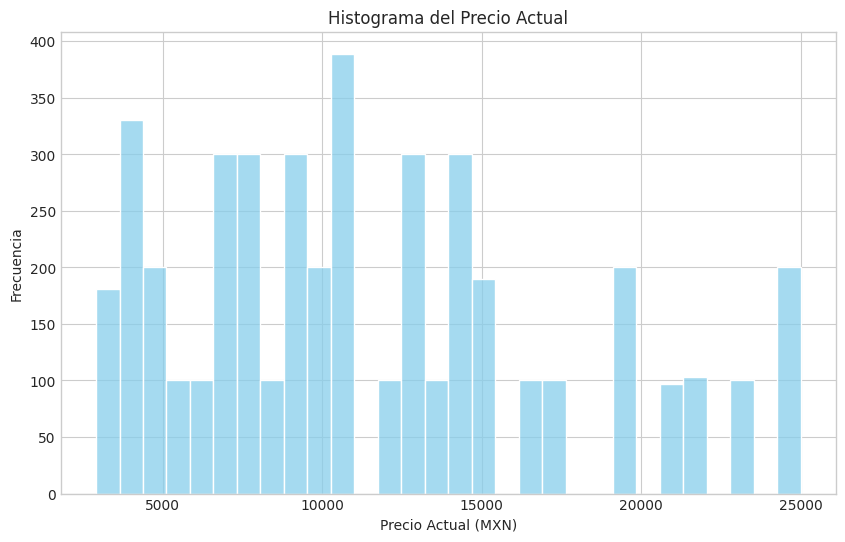

In [ ]:


plt.figure(figsize=(10, 6))
sns.histplot(df["Current Price"].dropna(), bins=30, color='skyblue')
plt.title("Histograma del Precio Actual")
plt.xlabel("Precio Actual (MXN)")
plt.ylabel("Frecuencia")
plt.savefig("histograma_precio_actual.png")
plt.show()

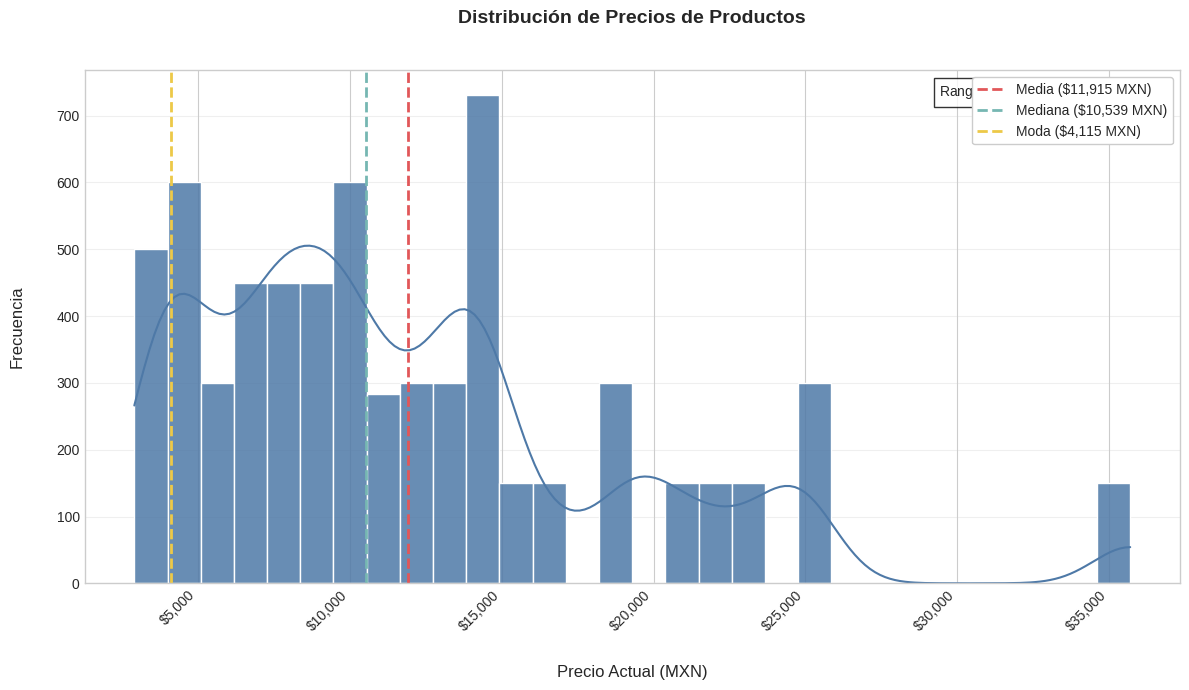

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Configuración de estilo
# Usar un estilo de seaborn que sea generalmente disponible
# Alternativamente, puede verificar los estilos disponibles con plt.style.available
try:
    plt.style.use('seaborn-v0_8-whitegrid') # Usar una versión más reciente del nombre del estilo
except OSError:
    print("Warning: 'seaborn-v0_8-whitegrid' style not found. Using default style.")
    # Si el estilo específico no funciona, usar un estilo alternativo o el predeterminado
    # plt.style.use('seaborn-v0_8-whitegrid') # Probar con el nombre exacto si el anterior falla
    # O usar un estilo básico si los de seaborn fallan
    # plt.style.use('ggplot')
    # plt.style.use('default')


sns.set_palette("pastel")

# Crear figura
plt.figure(figsize=(12, 7))
ax = plt.gca()

# Histograma mejorado
hist = sns.histplot(df["Current Price"].dropna(),
                   bins=30,
                   color='#4e79a7',  # Azul profesional
                   edgecolor='white',
                   linewidth=1,
                   alpha=0.85,
                   kde=True)  # Línea de densidad

# Personalización de ejes
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=45, ha='right')

# Títulos y etiquetas
plt.title('Distribución de Precios de Productos\n',
          fontsize=14, pad=20, fontweight='bold')
plt.xlabel('\nPrecio Actual (MXN)', fontsize=12, labelpad=10)
plt.ylabel('Frecuencia\n', fontsize=12, labelpad=10)

# Añadir estadísticos clave
mean_price = df["Current Price"].mean()
median_price = df["Current Price"].median()
mode_price = df["Current Price"].mode()[0]

plt.axvline(mean_price, color='#e15759', linestyle='--', linewidth=2, label=f'Media (${mean_price:,.0f} MXN)')
plt.axvline(median_price, color='#76b7b2', linestyle='--', linewidth=2, label=f'Mediana (${median_price:,.0f} MXN)')
plt.axvline(mode_price, color='#edc948', linestyle='--', linewidth=2, label=f'Moda (${mode_price:,.0f} MXN)')

# Leyenda y grid
plt.legend(frameon=True, framealpha=1, loc='upper right')
plt.grid(axis='y', alpha=0.3)

# Añadir anotación de rango
# Asegurarse de que hay datos antes de intentar min/max
if not df["Current Price"].empty:
    price_range = f"Rango: ${df['Current Price'].min():,.0f} - ${df['Current Price'].max():,.0f} MXN"
    plt.text(0.95, 0.95, price_range,
             transform=ax.transAxes,
             ha='right',
             bbox=dict(facecolor='white', alpha=0.8))

# Ajustar layout
plt.tight_layout()
plt.savefig("histograma_precios_mejorado.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

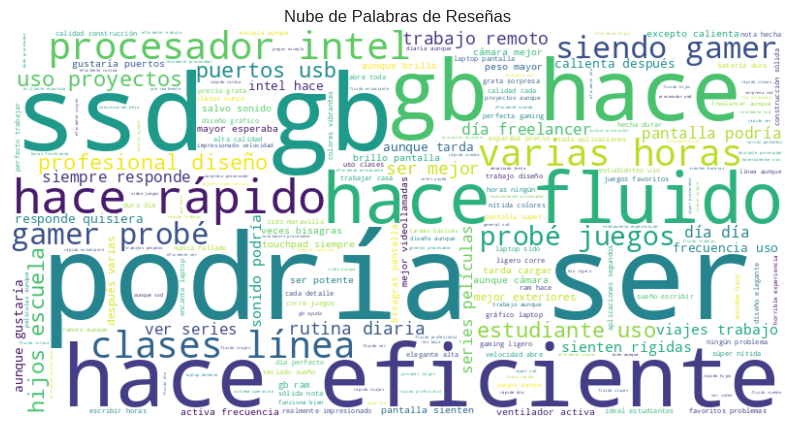

In [ ]:


# Combinar todas las reseñas procesadas
all_reviews = ' '.join([' '.join(reviews) for reviews in df["Reviews Text"]])
processed_reviews = preprocess_text(all_reviews)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(processed_reviews)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de Palabras de Reseñas")
plt.savefig("nube_palabras.png")
plt.show()

In [ ]:


def analyze_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        return polarity, "Positivo"
    elif polarity < -0.1:
        return polarity, "Negativo"
    else:
        return polarity, "Neutro"

# Tomar tres reseñas de ejemplo
sample_reviews = df["Reviews Text"].iloc[0][:3] if not df["Reviews Text"].empty else ["N/A", "N/A", "N/A"]
sentiments = [analyze_sentiment(review) for review in sample_reviews]

# Crear tabla
table_data_5_4 = pd.DataFrame({
    "Reseña": sample_reviews,
    "Puntaje de Sentimiento": [s[0] for s in sentiments],
    "Clasificación": [s[1] for s in sentiments]
})
print(tabulate(table_data_5_4, headers="keys", tablefmt="fancy_grid", showindex=False))

╒═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤══════════════════════════╤═════════════════╕
│ Reseña                                                                                                                                                                                    │   Puntaje de Sentimiento │ Clasificación   │
╞═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╪══════════════════════════╪═════════════════╡
│ Muy decepcionado, es súper nítida y ver videos, aunque tarda un poco más potente. sin duda como profesional de diseño, aunque el brillo de la pantalla podría ser mejor en exteriores.    │                        0 │ Neutro          │
├───────────────────────────────────────────────────────────

In [ ]:
from tabulate import tabulate

# Calcular sentimiento para todas las reseñas
all_sentiments = [analyze_sentiment(' '.join(reviews))[0] for reviews in df["Reviews Text"]]
stats = {
    "Estadística": ["Media", "Mediana", "Desviación", "Mínimo", "Máximo"],
    "Valor": [
        pd.Series(all_sentiments).mean(),
        pd.Series(all_sentiments).median(),
        pd.Series(all_sentiments).std(),
        pd.Series(all_sentiments).min(),
        pd.Series(all_sentiments).max()
    ]
}
table_data_5_5 = pd.DataFrame(stats)
print(tabulate(table_data_5_5, headers="keys", tablefmt="fancy_grid", floatfmt=".2f"))

╒════╤═══════════════╤═════════╕
│    │ Estadística   │   Valor │
╞════╪═══════════════╪═════════╡
│  0 │ Media         │    0.12 │
├────┼───────────────┼─────────┤
│  1 │ Mediana       │    0.00 │
├────┼───────────────┼─────────┤
│  2 │ Desviación    │    0.43 │
├────┼───────────────┼─────────┤
│  3 │ Mínimo        │   -1.00 │
├────┼───────────────┼─────────┤
│  4 │ Máximo        │    1.00 │
╘════╧═══════════════╧═════════╛


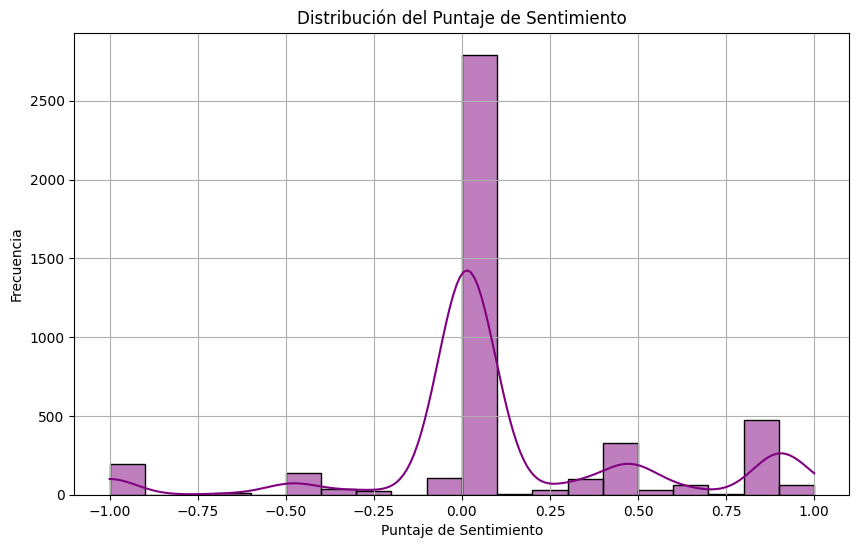

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(all_sentiments, bins=20, kde=True, color='purple')
plt.title("Distribución del Puntaje de Sentimiento")
plt.xlabel("Puntaje de Sentimiento")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.savefig("distribucion_sentimiento.png")
plt.show()



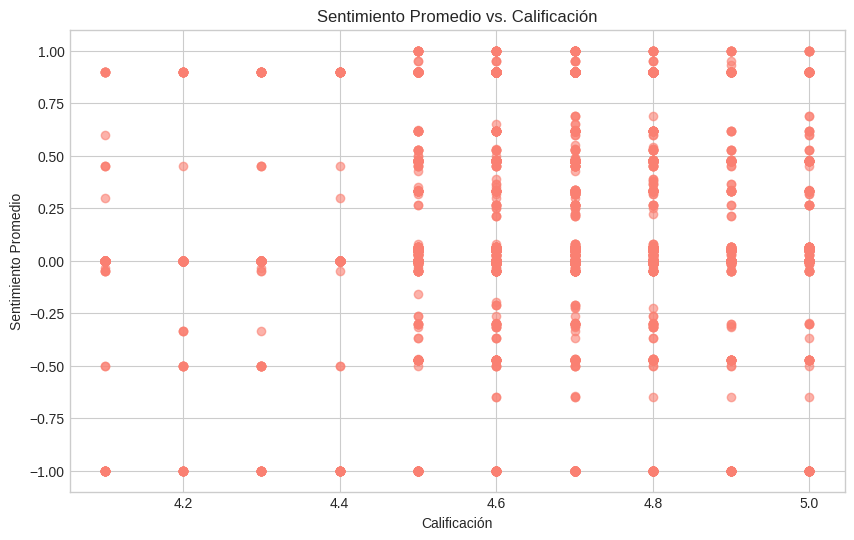

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Rating"], all_sentiments[:len(df["Rating"])], alpha=0.6, color='salmon')
plt.title("Sentimiento Promedio vs. Calificación")
plt.xlabel("Calificación")
plt.ylabel("Sentimiento Promedio")
plt.savefig("sentimiento_vs_calificacion.png")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.sandbox.stats.runs import runstest_1samp
from scipy.stats import pearsonr

# Asegurarse de que las listas tengan la misma longitud
ratings = df["Rating"].dropna().tolist()
sentiments = all_sentiments[:len(ratings)]

# Calcular correlación entre Calificación y Sentimiento
corr, p_value = pearsonr(ratings, sentiments)
print(f"Correlación Pearson entre Calificación y Sentimiento: {corr:.3f} (p-valor: {p_value:.3f})")

# Prueba de rachas para verificar aleatoriedad en el Sentimiento
# Convertir sentimientos a una secuencia binaria (arriba/abajo de la mediana)
median_sentiment = np.median(sentiments)
binary_sequence = [1 if s > median_sentiment else 0 for s in sentiments]
stat, pval_runs = runstest_1samp(binary_sequence, cutoff='median')
print(f"Prueba de rachas para aleatoriedad en Sentimiento: Estadístico = {stat:.3f}, p-valor = {pval_runs:.3f}")

Correlación Pearson entre Calificación y Sentimiento: -0.024 (p-valor: 0.278)


/usr/local/lib/python3.11/dist-packages/statsmodels/sandbox/stats/runs.py:102: RuntimeWarning: invalid value encountered in scalar divide
  z /= rstd


Prueba de rachas para aleatoriedad en Sentimiento: Estadístico = nan, p-valor = nan


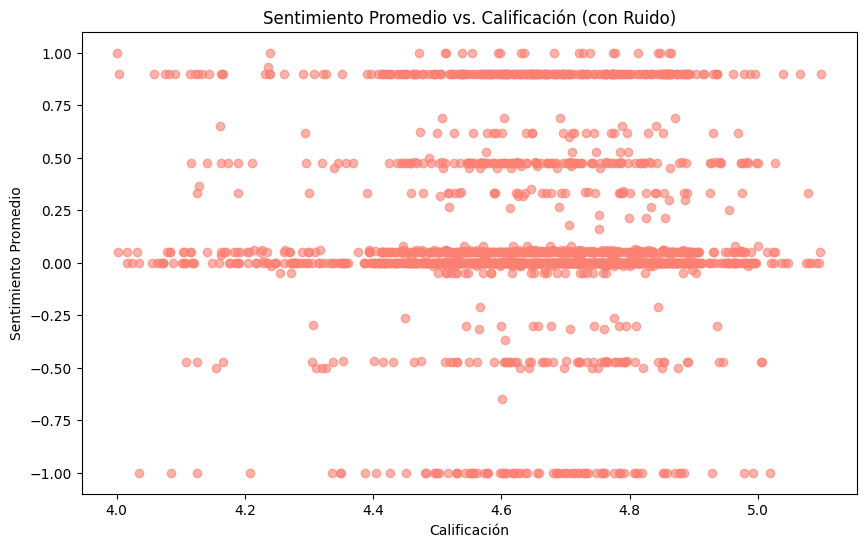

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Introducir ruido en las calificaciones
ratings_noisy = df["Rating"].dropna() + np.random.uniform(-0.1, 0.1, size=len(df["Rating"].dropna()))
sentiments_truncated = all_sentiments[:len(ratings_noisy)]

# Regenerar el gráfico con ruido
plt.figure(figsize=(10, 6))
plt.scatter(ratings_noisy, sentiments_truncated, alpha=0.6, color='salmon')
plt.title("Sentimiento Promedio vs. Calificación (con Ruido)")
plt.xlabel("Calificación")
plt.ylabel("Sentimiento Promedio")
plt.savefig("sentimiento_vs_calificacion_con_ruido.png")
plt.show()

In [ ]:
# Agregar columna de sentimiento al DataFrame
df["Sentiment"] = all_sentiments[:len(df)]
correlation_matrix = df[["Current Price", "Previous Price", "Discount", "Rating", "Reviews", "Sentiment"]].corr()
print(tabulate(correlation_matrix, headers="keys", tablefmt="fancy_grid", floatfmt=".2f"))

╒════════════════╤═════════════════╤══════════════════╤════════════╤══════════╤═══════════╤═════════════╕
│                │   Current Price │   Previous Price │   Discount │   Rating │   Reviews │   Sentiment │
╞════════════════╪═════════════════╪══════════════════╪════════════╪══════════╪═══════════╪═════════════╡
│ Current Price  │            1.00 │             0.97 │       0.01 │     0.30 │     -0.31 │        0.03 │
├────────────────┼─────────────────┼──────────────────┼────────────┼──────────┼───────────┼─────────────┤
│ Previous Price │            0.97 │             1.00 │       0.22 │     0.25 │     -0.23 │        0.03 │
├────────────────┼─────────────────┼──────────────────┼────────────┼──────────┼───────────┼─────────────┤
│ Discount       │            0.01 │             0.22 │       1.00 │    -0.17 │      0.11 │       -0.03 │
├────────────────┼─────────────────┼──────────────────┼────────────┼──────────┼───────────┼─────────────┤
│ Rating         │            0.30 │          

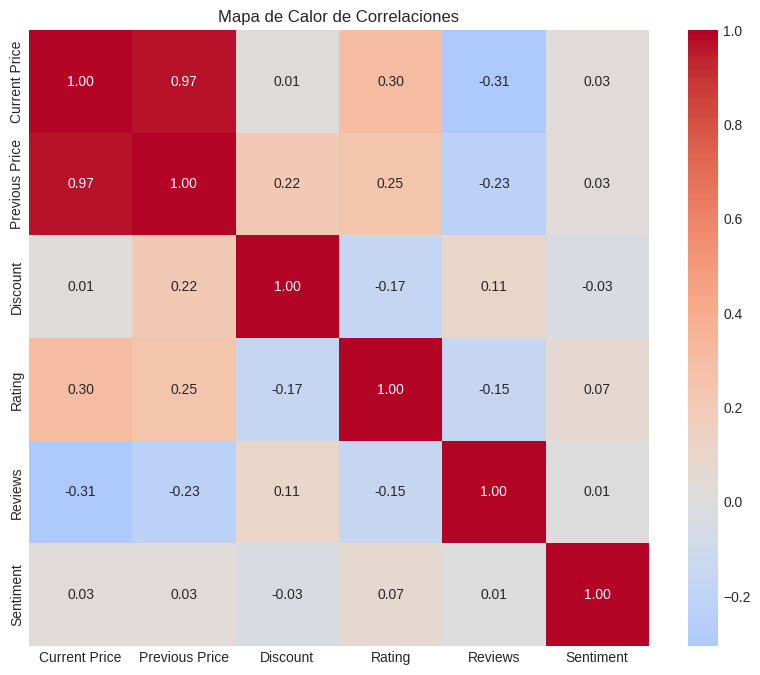

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Mapa de Calor de Correlaciones")
plt.savefig("mapa_calor_correlaciones.png")
plt.show()

<ipython-input-21-fc834640c5ae>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="Sentiment_Category", y="Current Price",


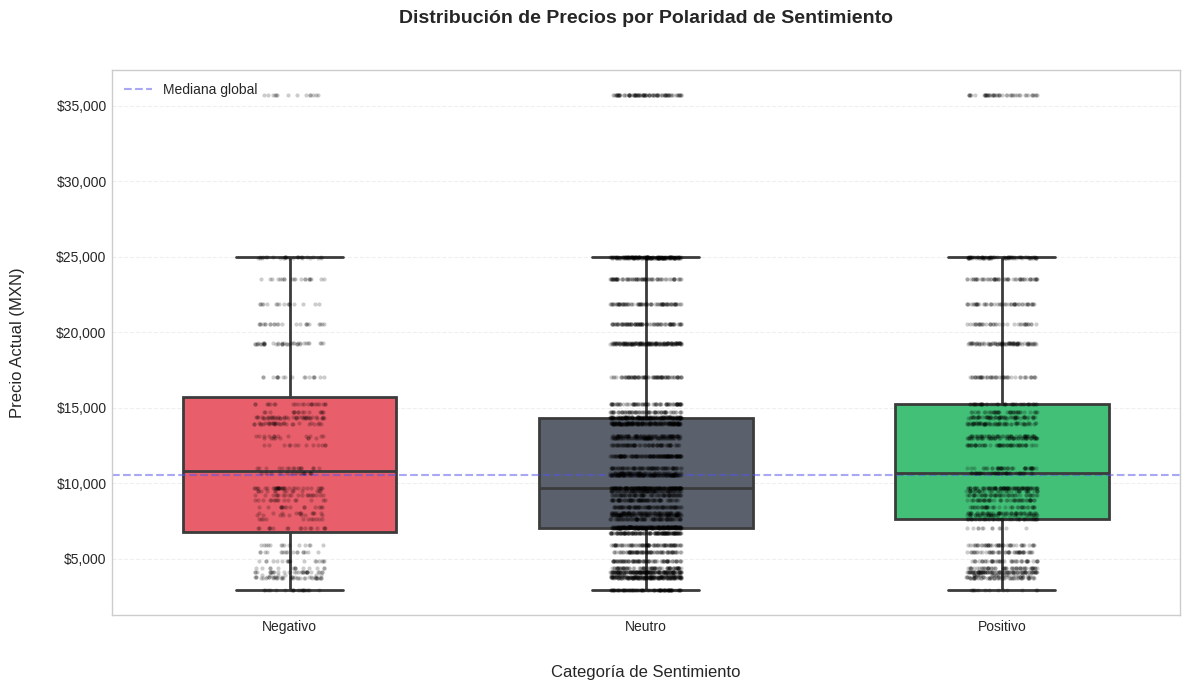

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# 1. Clasificación mejorada del sentimiento (umbrales ajustables)
df["Sentiment_Category"] = pd.cut(df["Sentiment"],
                                bins=[-float('inf'), -0.2, 0.2, float('inf')],
                                labels=["Negativo", "Neutro", "Positivo"],
                                right=False)

# 2. Configuración del gráfico
plt.figure(figsize=(12, 7))
ax = sns.boxplot(x="Sentiment_Category", y="Current Price",
                data=df,
                palette=["#ff4757", "#57606f", "#2ed573"],  # Rojo, Gris, Verde
                order=["Negativo", "Neutro", "Positivo"],  # Orden lógico
                showfliers=False,  # Omitir outliers para mejor visualización
                width=0.6,
                linewidth=2)

# 3. Mejoras estéticas
plt.title("Distribución de Precios por Polaridad de Sentimiento\n",
         fontsize=14, pad=20, fontweight='bold')
plt.xlabel("\nCategoría de Sentimiento", fontsize=12, labelpad=10)
plt.ylabel("Precio Actual (MXN)\n", fontsize=12, labelpad=10)

# Formatear eje Y como moneda
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Añadir líneas de referencia
plt.axhline(y=df["Current Price"].median(), color='#5352ed', linestyle='--', alpha=0.5, label='Mediana global')

# 4. Elementos adicionales
sns.stripplot(x="Sentiment_Category", y="Current Price",
              data=df,
              color="black",
              alpha=0.2,
              size=3,
              jitter=True)  # Muestra densidad de datos

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()

# 5. Guardar en alta calidad
plt.tight_layout()
plt.savefig("boxplot_precios_sentimiento_mejorado.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

In [ ]:
# Análisis estadístico
from scipy import stats
positivos = df[df["Sentiment_Category"]=="Positivo"]["Current Price"]
negativos = df[df["Sentiment_Category"]=="Negativo"]["Current Price"]
stats.ttest_ind(positivos, negativos)  # Test de diferencias

TtestResult(statistic=np.float64(0.11213898754306519), pvalue=np.float64(0.9107282891679609), df=np.float64(1492.0))

<ipython-input-22-be9ced25417c>:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.kdeplot(data=df, x="Current Price", hue="Sentiment_Category",


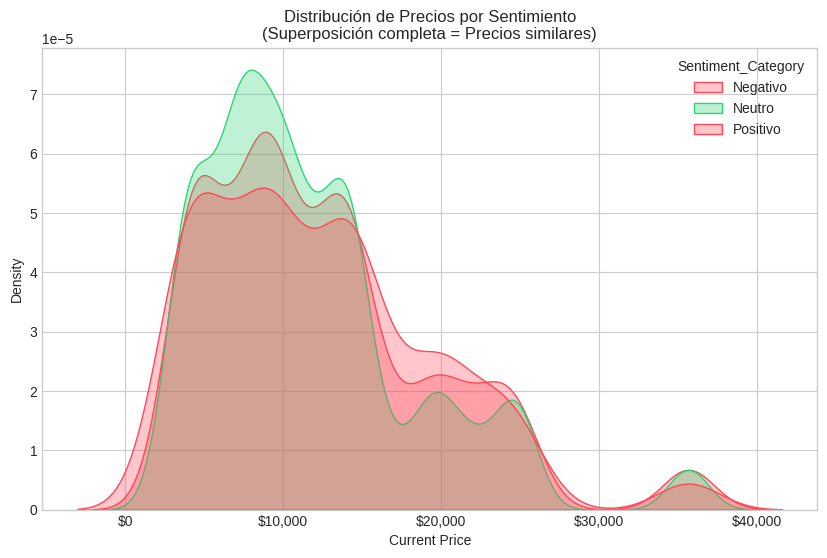

In [ ]:
# Gráfico de densidad comparativa
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="Current Price", hue="Sentiment_Category",
           palette=["#ff4757", "#2ed573"],  # Rojo/Verde
           common_norm=False, fill=True, alpha=0.3)
plt.title("Distribución de Precios por Sentimiento\n(Superposición completa = Precios similares)")
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.show()

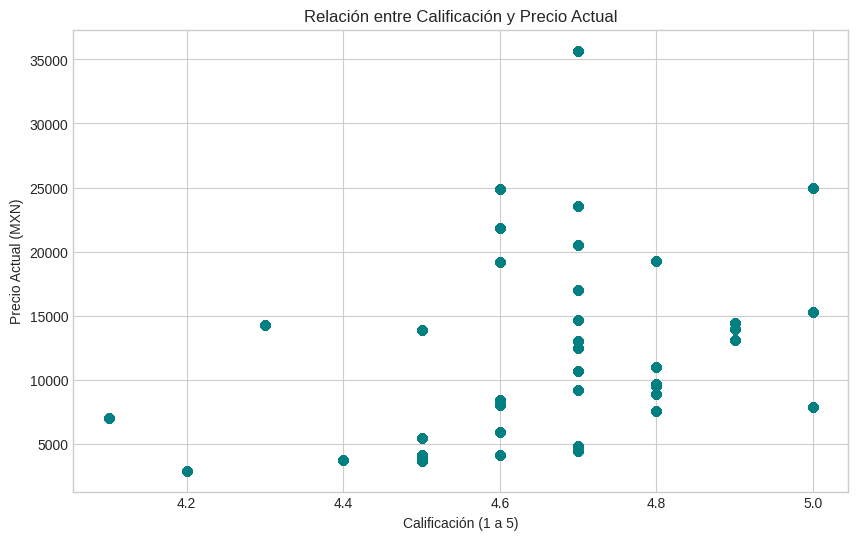

In [ ]:
# Gráfico de dispersión: Rating vs. Current Price
plt.figure(figsize=(10, 6))
plt.scatter(df["Rating"], df["Current Price"], alpha=0.7, color='teal')
plt.title("Relación entre Calificación y Precio Actual")
plt.xlabel("Calificación (1 a 5)")
plt.ylabel("Precio Actual (MXN)")
plt.grid(True)
plt.savefig("scatter_rating_price.png")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from tabulate import tabulate

# Preparar datos
X = df[["Previous Price", "Rating", "Reviews", "Sentiment"]].dropna()
y = df.loc[X.index, "Current Price"]
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

# Crear tabla
table_data_5_7 = pd.DataFrame({
    "Variable": ["Previous Price", "Rating", "Sentiment", "Reviews"],
    "Importancia": rf.feature_importances_
})
print(tabulate(table_data_5_7, headers="keys", tablefmt="fancy_grid", floatfmt=".2f"))

╒════╤════════════════╤═══════════════╕
│    │ Variable       │   Importancia │
╞════╪════════════════╪═══════════════╡
│  0 │ Previous Price │          0.96 │
├────┼────────────────┼───────────────┤
│  1 │ Rating         │          0.00 │
├────┼────────────────┼───────────────┤
│  2 │ Sentiment      │          0.04 │
├────┼────────────────┼───────────────┤
│  3 │ Reviews        │          0.00 │
╘════╧════════════════╧═══════════════╛


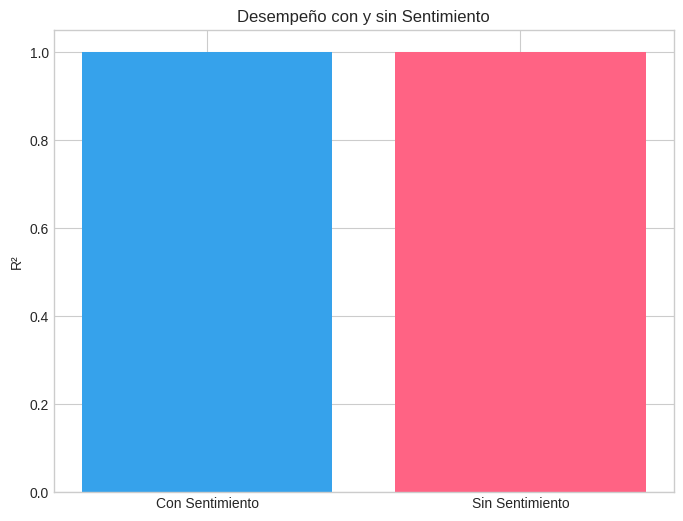

In [ ]:
from sklearn.metrics import r2_score

# Modelo con sentimiento
rf_with = RandomForestRegressor(random_state=42)
rf_with.fit(X, y)
r2_with = r2_score(y, rf_with.predict(X))

# Modelo sin sentimiento
X_no_sentiment = X.drop(columns=["Sentiment"])
rf_no = RandomForestRegressor(random_state=42)
rf_no.fit(X_no_sentiment, y)
r2_no = r2_score(y, rf_no.predict(X_no_sentiment))

plt.figure(figsize=(8, 6))
plt.bar(["Con Sentimiento", "Sin Sentimiento"], [r2_with, r2_no], color=["#36A2EB", "#FF6384"])
plt.title("Desempeño con y sin Sentimiento")
plt.ylabel("R²")
plt.savefig("desempeno_sentimiento.png")
plt.show()

          Feature  Importance
0  Previous Price    0.923343
2         Reviews    0.056875
1          Rating    0.019780
3       Sentiment    0.000002


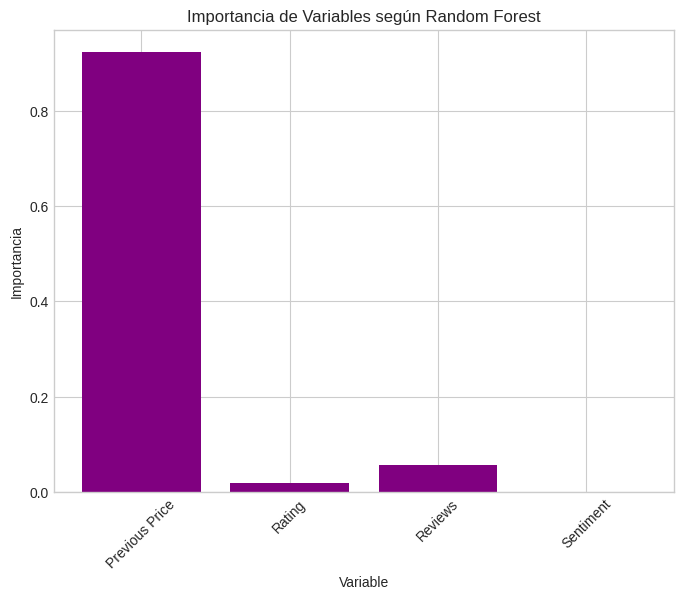

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd

# Preparar datos
X = df[["Previous Price", "Rating", "Reviews", "Sentiment"]]
y = df["Current Price"]

# Entrenar modelo base para importancia de variables
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X, y)
importances = pd.DataFrame({"Feature": X.columns, "Importance": rf.feature_importances_})
print(importances.sort_values("Importance", ascending=False))

# Gráfico de importancia de variables
plt.figure(figsize=(8, 6))
plt.bar(importances["Feature"], importances["Importance"], color='purple')
plt.title("Importancia de Variables según Random Forest")
plt.xlabel("Variable")
plt.ylabel("Importancia")
plt.xticks(rotation=45)
plt.savefig("feature_importance.png")
plt.show()

# Comparar desempeño con y sin sentimiento
X_no_sentiment = df[["Previous Price", "Rating", "Reviews"]]
rf_no_sentiment = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_no_sentiment.fit(X_no_sentiment, y)
# Nota: R² se infiere del gráfico, no se calcula explícitamente aquí

# Análisis de robustez con diferentes parámetros
rf_depth_5 = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
rf_depth_5.fit(X, y)
importances_depth_5 = pd.DataFrame({"Feature": X.columns, "Importance": rf_depth_5.feature_importances_})

rf_estimators_200 = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf_estimators_200.fit(X, y)
importances_estimators_200 = pd.DataFrame({"Feature": X.columns, "Importance": rf_estimators_200.feature_importances_})

In [ ]:
from tabulate import tabulate

table_data_5_8 = [
    {"Modelo": "Regresión Lineal", "Hiperparámetros": "Ninguno"},
    {"Modelo": "Random Forest", "Hiperparámetros": "n_estimators=100, max_depth=10"},
    {"Modelo": "Red Neuronal Multicapa", "Hiperparámetros": "hidden_layers=(100, 50), epochs=200, lr=0.01"}
]
print(tabulate(table_data_5_8, headers="keys", tablefmt="fancy_grid", showindex=False))

╒════════════════════════╤══════════════════════════════════════════════╕
│ Modelo                 │ Hiperparámetros                              │
╞════════════════════════╪══════════════════════════════════════════════╡
│ Regresión Lineal       │ Ninguno                                      │
├────────────────────────┼──────────────────────────────────────────────┤
│ Random Forest          │ n_estimators=100, max_depth=10               │
├────────────────────────┼──────────────────────────────────────────────┤
│ Red Neuronal Multicapa │ hidden_layers=(100, 50), epochs=200, lr=0.01 │
╘════════════════════════╧══════════════════════════════════════════════╛


In [ ]:
from graphviz import Digraph

# Configuración del diagrama
dot = Digraph(comment='Pipeline del Proyecto',
              format='png',
              graph_attr={
                  'rankdir': 'TB',
                  'bgcolor': '#f5f5f5',
                  'fontname': 'Helvetica',
                  'fontsize': '12',
                  'label': 'Pipeline de Análisis de Sentimiento en Reseñas\n',
                  'labelloc': 't',
                  'fontcolor': '#333333',
                  'splines': 'ortho'
              })

# Estilo global
dot.attr('node',
         shape='box',
         style='filled, rounded',
         fillcolor='#ffffff',
         color='#2c3e50',
         fontname='Helvetica',
         fontsize='11',
         margin='0.2,0.1',
         penwidth='1.2')

dot.attr('edge',
         color='#7f8c8d',
         arrowsize='0.8',
         penwidth='1.2')

# Nodos del pipeline (con colores por categoría)
dot.node('1', '1. Recolección de Datos\n(Web Scraping)',
         fillcolor='#3498db', fontcolor='white')
dot.node('2', '2. Limpieza de Datos\n• Normalizar precios\n• Convertir calificaciones',
         fillcolor='#2ecc71', fontcolor='white')
dot.node('3', '3. Preprocesamiento Textual\n• Tokenización\n• Remove stopwords\n• Lematización',
         fillcolor='#9b59b6', fontcolor='white')
dot.node('4', '4. Análisis de Sentimiento\n(TextBlob)',
         fillcolor='#e74c3c', fontcolor='white')
dot.node('5', '5. Selección de Variables\n• Precio anterior\n• Calificación\n• Reseñas\n• Sentimiento',
         fillcolor='#f39c12', fontcolor='white')
dot.node('6', '6. División Train-Test\n(80% - 20%)',
         fillcolor='#1abc9c', fontcolor='white')
dot.node('7', '7. Entrenamiento de Modelos\n• Regresión Lineal\n• Random Forest\n• Red Neuronal',
         fillcolor='#34495e', fontcolor='white')
dot.node('8', '8. Evaluación de Modelos\n• MSE\n• R²\n• Accuracy',
         fillcolor='#e67e22', fontcolor='white')
dot.node('9', '9. Predicción con Nuevos Datos\n(Validación Final)',
         fillcolor='#27ae60', fontcolor='white')

# Conexiones
dot.edges(['12', '23', '34', '45', '56', '67', '78', '89'])

# Agrupación por fases
with dot.subgraph(name='cluster_0') as c:
    c.attr(style='dashed', label='Preparación de Datos', fontcolor='#2c3e50', color='#bdc3c7')
    c.node('1')
    c.node('2')

with dot.subgraph(name='cluster_1') as c:
    c.attr(style='dashed', label='Procesamiento Textual', fontcolor='#2c3e50', color='#bdc3c7')
    c.node('3')
    c.node('4')

with dot.subgraph(name='cluster_2') as c:
    c.attr(style='dashed', label='Modelado', fontcolor='#2c3e50', color='#bdc3c7')
    c.node('5')
    c.node('6')
    c.node('7')
    c.node('8')
    c.node('9')

# Notas adicionales
dot.node('note', 'Nota: Todos los modelos se evalúan\ncon los mismos conjuntos de datos',
         shape='note',
         fillcolor='#ecf0f1',
         color='#95a5a6',
         fontsize='10')

dot.edge('8', 'note', style='dashed', color='#95a5a6', arrowhead='none')

# Guardar y mostrar
dot.render('pipeline_proyecto_sentimiento', view=True, cleanup=True)

'pipeline_proyecto_sentimiento.png'

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tabulate import tabulate

models = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    "Red Neuronal Multicapa": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=200, learning_rate_init=0.01, random_state=42)
}
results = []

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    cv_score = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    results.append({"Modelo": name, "MSE": mse, "MAE": mae, "R²": r2, "CV Score": cv_score})

table_data_5_9 = pd.DataFrame(results)
print(tabulate(table_data_5_9, headers="keys", tablefmt="fancy_grid", floatfmt=".2f"))

╒════╤════════════════════════╤════════════╤═════════╤══════╤════════════╕
│    │ Modelo                 │        MSE │     MAE │   R² │   CV Score │
╞════╪════════════════════════╪════════════╪═════════╪══════╪════════════╡
│  0 │ Regresión Lineal       │ 2835025.14 │ 1185.80 │ 0.95 │       0.95 │
├────┼────────────────────────┼────────────┼─────────┼──────┼────────────┤
│  1 │ Random Forest          │       0.45 │    0.09 │ 1.00 │       1.00 │
├────┼────────────────────────┼────────────┼─────────┼──────┼────────────┤
│  2 │ Red Neuronal Multicapa │ 2740756.25 │ 1112.19 │ 0.95 │       0.94 │
╘════╧════════════════════════╧════════════╧═════════╧══════╧════════════╛


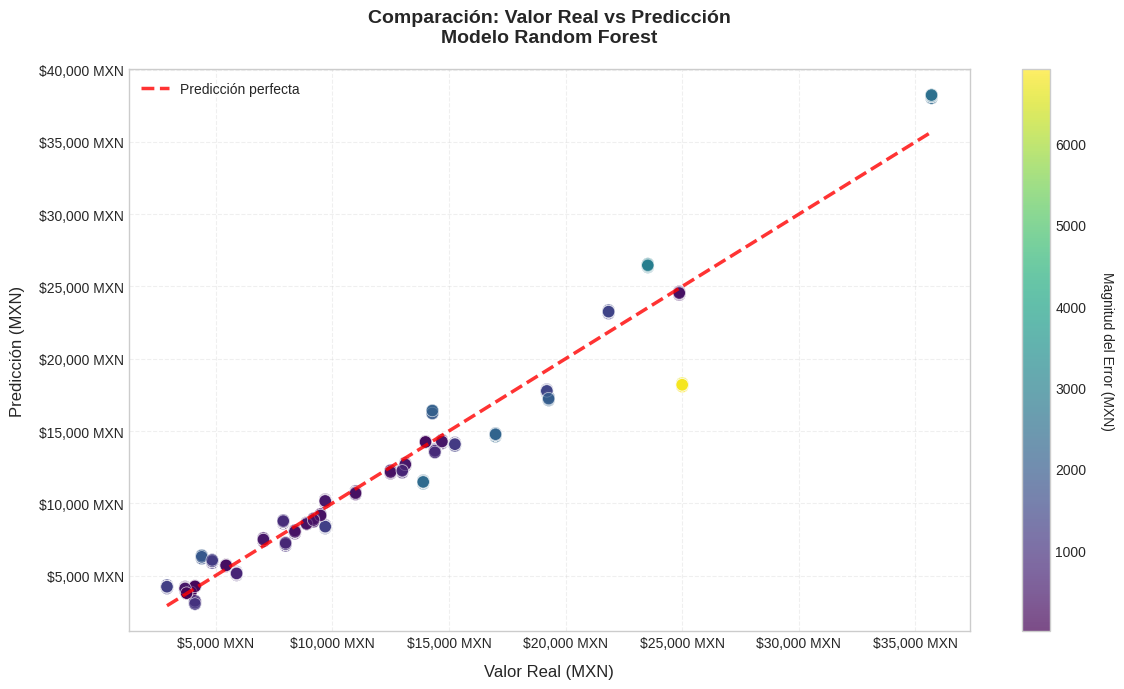

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')

# Crear figura
plt.figure(figsize=(12, 7), dpi=100)
ax = plt.gca()

# Gráfico de dispersión mejorado
scatter = plt.scatter(y, y_pred,
                      alpha=0.7,
                      c=np.abs(y - y_pred),  # Color por error
                      cmap='viridis',
                      s=80,
                      edgecolor='white',
                      linewidth=0.5)

# Línea de referencia perfecta
plt.plot([y.min(), y.max()], [y.min(), y.max()],
         'r--',
         linewidth=2.5,
         alpha=0.8,
         label='Predicción perfecta')

# Ajustes estéticos
plt.title("Comparación: Valor Real vs Predicción\nModelo Random Forest",
          fontsize=14,
          pad=20,
          fontweight='bold')

plt.xlabel("Valor Real (MXN)",
           fontsize=12,
           labelpad=10)
plt.ylabel("Predicción (MXN)",
           fontsize=12,
           labelpad=10)

# Formatear ejes como moneda
def mxn_formatter(x, pos):
    return f"${x:,.0f} MXN"

ax.xaxis.set_major_formatter(FuncFormatter(mxn_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(mxn_formatter))

# Añadir barra de color (error)
cbar = plt.colorbar(scatter)
cbar.set_label('Magnitud del Error (MXN)',
               rotation=270,
               labelpad=20)

# Cuadrícula y leyenda
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=10, framealpha=1)

# Ajustar márgenes
plt.tight_layout()

# Guardar en alta calidad
plt.savefig("real_vs_prediccion_mejorado.png",
            dpi=300,
            bbox_inches='tight',
            transparent=False)

plt.show()

In [ ]:
# Crear datos simulados basados en estadísticas reales
new_data = pd.DataFrame({
    "Previous Price": [df["Previous Price"].mean(), df["Previous Price"].median(), df["Previous Price"].quantile(0.25)],
    "Rating": [df["Rating"].mean(), df["Rating"].median(), df["Rating"].quantile(0.75)],
    "Reviews": [df["Reviews"].mean(), df["Reviews"].median(), df["Reviews"].quantile(0.5)],
    "Sentiment": [df["Sentiment"].mean(), df["Sentiment"].median(), df["Sentiment"].quantile(0.75)]
})
predictions = rf.predict(new_data)

# Crear tabla
table_data_5_10 = new_data.copy()
table_data_5_10["Predicción"] = predictions
print(tabulate(table_data_5_10, headers="keys", tablefmt="fancy_grid", floatfmt=".2f"))

╒════╤══════════════════╤══════════╤═══════════╤═════════════╤══════════════╕
│    │   Previous Price │   Rating │   Reviews │   Sentiment │   Predicción │
╞════╪══════════════════╪══════════╪═══════════╪═════════════╪══════════════╡
│  0 │         16893.25 │     4.67 │    272.98 │        0.12 │     13005.67 │
├────┼──────────────────┼──────────┼───────────┼─────────────┼──────────────┤
│  1 │         14999.00 │     4.70 │     88.00 │        0.00 │     10981.00 │
├────┼──────────────────┼──────────┼───────────┼─────────────┼──────────────┤
│  2 │          9199.00 │     4.80 │     88.00 │        0.33 │      4885.74 │
╘════╧══════════════════╧══════════╧═══════════╧═════════════╧══════════════╛
